In [1]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt
import sys

from chemrixs.avrg import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

In [2]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
#run = 104 #XAS step mono
#run = 119 #waveplate
#run = 151 #fixed energy
#run = 76 #XAS fly mono

bgrun = 61
# run = 10
runs=[22,23,26]
run=39

#exp = 'rix100836924'
# exp = 'rix101265125'
exp = 'rix101331225'
#79,81,82,83,85,94,95,96,98


fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'

avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
             raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
             save= True,norm = True)

# data = SmallData(fname,fyaml)
# bg = SmallData(bgname, bgyaml)



proc/Run
['axis_svls_off_mean', 'axis_svls_off_std', 'axis_svls_off_sum', 'axis_svls_on_mean', 'axis_svls_on_std', 'axis_svls_on_sum', 'scanvar_off', 'scanvar_on']
<HDF5 dataset "axis_svls_off_mean": shape (39, 796), type "<f4">
<HDF5 dataset "axis_svls_off_std": shape (39, 796), type "<f4">
<HDF5 dataset "axis_svls_off_sum": shape (39, 796), type "<f4">
<HDF5 dataset "axis_svls_on_mean": shape (39, 796), type "<f4">
<HDF5 dataset "axis_svls_on_std": shape (39, 796), type "<f4">
<HDF5 dataset "axis_svls_on_sum": shape (39, 796), type "<f4">
<HDF5 dataset "scanvar_off": shape (39,), type "<f4">
<HDF5 dataset "scanvar_on": shape (39,), type "<f4">
<HDF5 dataset "axis_svls_off_mean": shape (39, 796), type "<f4">
<HDF5 dataset "axis_svls_off_std": shape (39, 796), type "<f4">
<HDF5 dataset "axis_svls_off_sum": shape (39, 796), type "<f4">
<HDF5 dataset "axis_svls_on_mean": shape (39, 796), type "<f4">
<HDF5 dataset "axis_svls_on_std": shape (39, 796), type "<f4">
<HDF5 dataset "axis_svls_o

In [3]:
for run in runs:
    fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
    red = Reduced(fname,bgname,fyaml,bgyaml, save=True)



avg=avg_data(runs,proc_folder)

61
setting up properties
scanvariable unknown
apds does not exits 
22
setting up properties
mono_fly
fly scan!
[520.9910199  521.10580891 520.996947   ... 521.01587739 521.00963509
 521.00599529]
bin_edges 40
[521.         521.23076923 521.46153846 521.69230769 521.92307692
 522.15384615 522.38461538 522.61538462 522.84615385 523.07692308
 523.30769231 523.53846154 523.76923077 524.         524.23076923
 524.46153846 524.69230769 524.92307692 525.15384615 525.38461538
 525.61538462 525.84615385 526.07692308 526.30769231 526.53846154
 526.76923077 527.         527.23076923 527.46153846 527.69230769
 527.92307692 528.15384615 528.38461538 528.61538462 528.84615385
 529.07692308 529.30769231 529.53846154 529.76923077 530.        ]
bin_axis 520.9846318973639 530.0242180203646
bin_edges 521.0 530.0
bin_width [0.23076923 0.23076923 0.23076923 0.23076923 0.23076923 0.23076923
 0.23076923 0.23076923 0.23076923 0.23076923 0.23076923 0.23076923
 0.23076923 0.23076923 0.23076923 0.23076923 0.2307

In [11]:
red.data.integrating.axis_svls.mono.max()

530.0117018562155

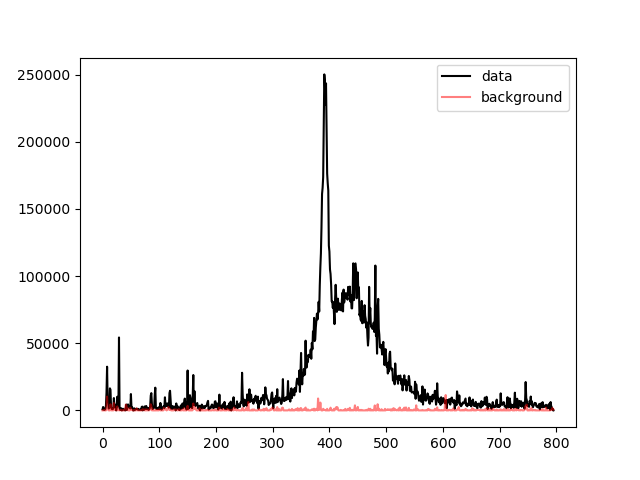

In [7]:
fig,ax=plt.subplots()
ax.plot(np.nansum(red.data.integrating.axis_svls.full_area,axis=0),'k',label='data')
ax.plot(np.nansum(red.bg.integrating.axis_svls.full_area,axis=0),'r',alpha=0.5,label='background')
ax.legend()
# ax.plot(np.nansum(red.proc,axis=0),'k')
# ax.plot(np.nansum(red.proc.svls,axis=0),'r')

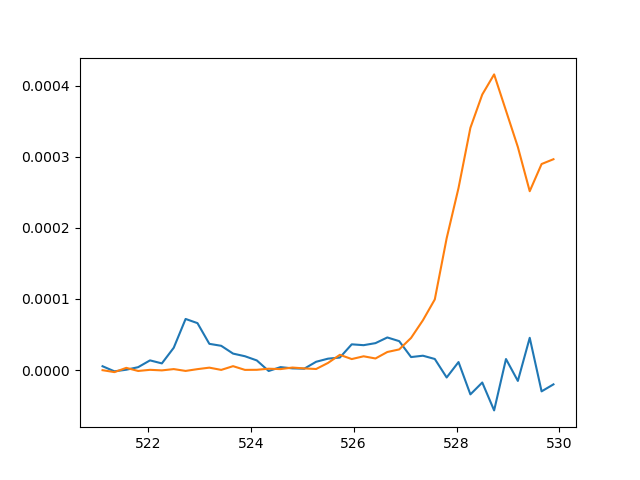

In [4]:
fig,ax=plt.subplots(1,1)
ax.plot(red.scanvar_on,np.sum(red.axis_svls_on_mean,1)-np.sum(red.axis_svls_off_mean,1))
ax.plot(red.scanvar_off,np.sum(red.axis_svls_off_mean,1))
# ax.set_xlim([red.scanvar_on.min(),red.scanvar_on.max()])

NameError: name 'avg' is not defined

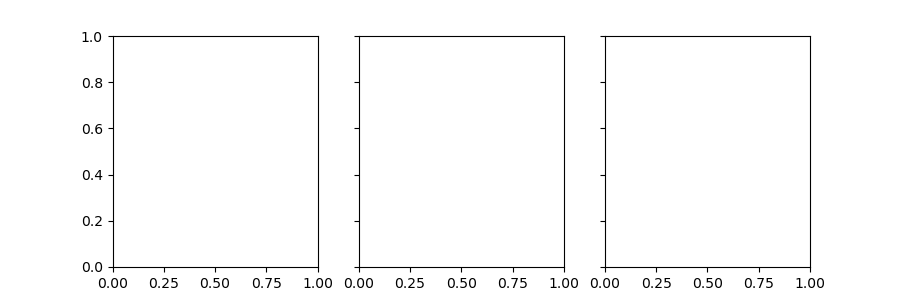

In [6]:
fig,ax=plt.subplots(1,3,figsize=(9,3),sharex=True,sharey=True)
ax[0].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_off_sum']))
ddat=np.nanmax(np.abs(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='RdBu')
ax[0].set_xlim([avg['scanvar_off'].min(),avg['scanvar_off'].max()])

In [8]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

# if emi_calib == []:
#     if data.runinfo == 'mono':
emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
            dat=avg['axis_svls_sum'], 
            mono = avg['scanvar'], 
            calib=emi_calib, 
                points = points)
#     else:
#         print('need mono scan to calibrate using emission axis')
# else:
#     emi,calib =pixel2emi(np.arange(avg['axis_svls_sum'].shape[1]), mono=[],
#                     dat=avg['axis_svls_sum'], 
#                     calib=emi_calib) 
                    
# if data.runinfo == 'mono':
mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
# else:
#     E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

KeyError: 'axis_svls_sum'

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

if emi_calib == []:
    if data.scantype == 'mono':
        emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    mono = avg['scanvar_on'], 
                    calib=emi_calib, 
                    points = points)
    else:
        print('need mono scan to calibrate using emission axis')
else:
    emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    calib=emi_calib) 
                    
if data.scantype == 'mono':
    mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
    mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_off'],emi,avg['axis_svls_off_sum'],step=0.1)
else:
    E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

<KeysViewHDF5 ['Sums', 'epics_archiver', 'intg', 'scan', 'timestamp', 'timing']>


UnboundLocalError: cannot access local variable 'scantype' where it is not associated with a value

In [1]:
fig,ax=plt.subplots(1,3)
ax[0].pcolor(avg['scanvar_on'],emi,avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))



NameError: name 'plt' is not defined

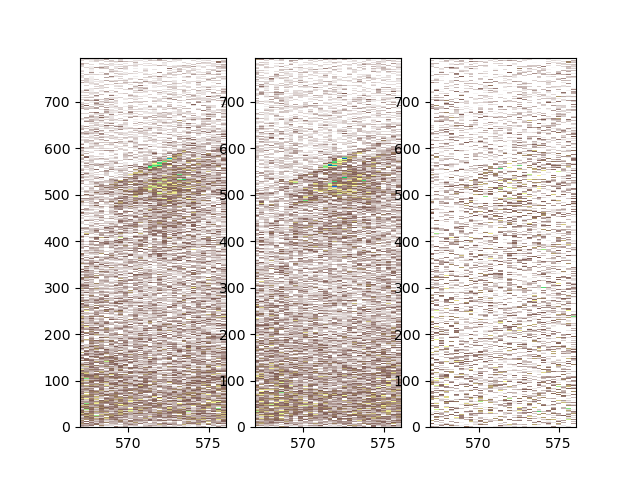

In [4]:

fig,ax=plt.subplots(1,3)
ax[0].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_off_mean))
ax[1].pcolor(red.scanvar_off,np.arange(red.axis_svls_off_mean.shape[1]),red.axis_svls_off_mean.T,cmap='terrain_r',vmin=0,vmax=np.max(red.axis_svls_off_mean))
ax[2].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T-red.axis_svls_off_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_on_mean-red.axis_svls_off_mean))


In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [5]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
#run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
run=310
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1['intg']['andor_vls']['scan_sum_lxt_ttc']
# test1['scan']['lxt_ttc']

<HDF5 dataset "scan_sum_lxt_ttc": shape (16292, 1), type "<f8">

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy

['/epics_archiver/SP1K1_MONO_MMS_M_PI.RBV']


In [1]:
testfile = h5py.File('testsave.h5','w')
keys = vars(red)
avg = {}
for key in keys:
    avg[key] = np.zeros(testfile[key].shape)

for dat in keys:
    if 'on' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])
    elif 'off' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])


testfile.close()

NameError: name 'h5py' is not defined

In [6]:
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    h5dump(tmp)


NameError: name 'h5dump' is not defined

In [52]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
exp = 'rix101331225'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0061.h5'

with h5py.File(fname,'r') as file:
    print(file['intg']['axis_svls']['mono_hrencoder_sum_value'][:100])

[-68145524 -68146335 -68009450 -68145711 -68009835 -68144790 -68009278
 -68145375 -68009121 -68145364 -68145557 -68009397 -68009328 -68009748
 -68008726 -68009137 -68009614 -68009610 -68008988 -68010140 -68009900
 -68008876 -68009729 -68009567 -68009457 -68009130 -68010286 -68010052
 -68009266 -68010016 -68009672 -68009808 -68009971 -68008986 -68009060
 -68009674 -68009882 -68010005 -68009328 -68009294 -68009743 -68009707
 -68009513 -68010282 -68009918 -68009660 -68009846 -68009727 -68009210
 -68009448 -68009623 -68009454 -68009806 -68009771 -68010127 -68009947
 -68009200 -68010377 -68009120 -68008821 -68010355 -68009771 -68009895
 -68009345 -68009947 -68010276 -68009715 -68009834 -68009364 -68009515
 -68010256 -68010043 -68009173 -68009827 -68009314 -68010176 -68009959
 -68010098 -56448193 -58080266 -68009862 -66377585 -45702828 -55632197
 -63248826 -50054920 -68009665 -67193935 -53183293 -68009887 -37269535
 -38765648 -61209050 -64744798 -59848922 -53455530 -46518533 -34548812
 -6814

In [4]:

with h5py.File('proc/Run0023.h5','r') as file:
    print(file.keys())

<KeysViewHDF5 []>
